In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import numpy.ma as ma
from domain import *
import xarray as xr
from netCDF4 import Dataset
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import calendar

In [2]:
dsMA=xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')
dsHMA = field_dom(dsMA,'HMA')
dsSH_hma=dsHMA['elevation']
LONS_hma,LATS_hma=dsHMA.longitude,dsHMA.latitude

In [3]:
#CH
dsCH=field_dom(dsHMA,'CH')
dsSH_CH=dsCH['elevation']
LONS_CH,LATS_CH=dsCH.longitude,dsCH.latitude

#HK
dsHK=field_dom(dsHMA,'HK')
dsSH_HK=dsHK['elevation']
LONS_HK,LATS_HK=dsHK.longitude,dsHK.latitude

#TP
dsTP=field_dom(dsHMA,'TP')
dsSH_TP=dsTP['elevation']
LONS_TP,LATS_TP=dsTP.longitude,dsTP.latitude

#SEH
dsSEH=field_dom(dsHMA,'SEH')
dsSH_SEH=dsSEH['elevation']
LONS_SEH,LATS_SEH=dsSEH.longitude,dsSEH.latitude

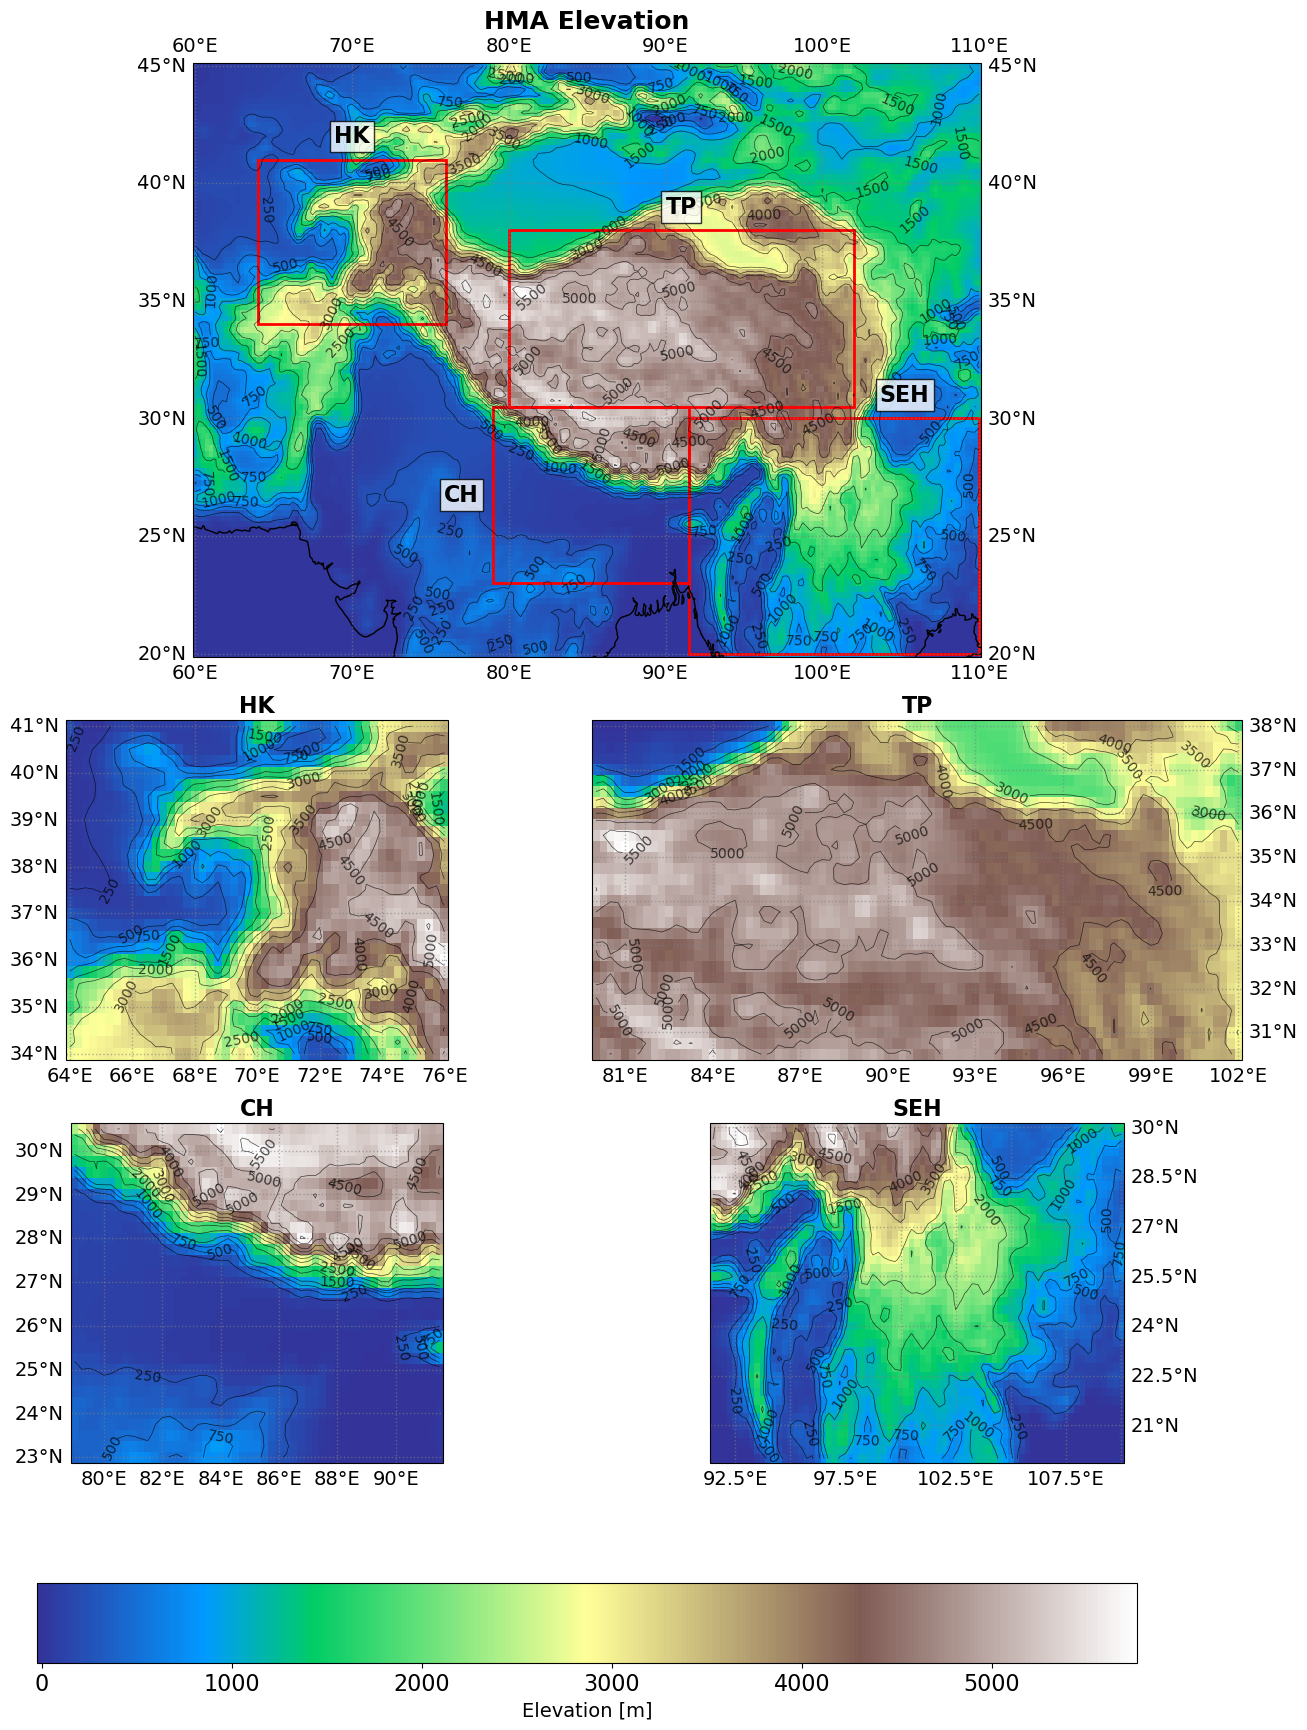

In [5]:
cmap='terrain'

# Compute rectangle coordinates automatically
CH_box = [LONS_CH.min().item(), LONS_CH.max().item(),
             LATS_CH.min().item(), LATS_CH.max().item()]

HK_box = [LONS_HK.min().item(), LONS_HK.max().item(),
             LATS_HK.min().item(), LATS_HK.max().item()]

TP_box = [LONS_TP.min().item(), LONS_TP.max().item(),
             LATS_TP.min().item(), LATS_TP.max().item()]

SEH_box = [LONS_SEH.min().item(), LONS_SEH.max().item(),
             LATS_SEH.min().item(), LATS_SEH.max().item()]

# Create figure and gridspec layout
fig = plt.figure(figsize=(22, 40))
gs = fig.add_gridspec(3, 2, height_ratios=[1.75, 1, 1])

# Row 1: full-width HMA plot
ax0 = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
CS0 = ax0.pcolormesh(LONS_hma, LATS_hma,dsSH_hma,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,shading="auto")
ax0.coastlines()
ax0.set_title('HMA Elevation',fontsize=18,weight="bold")
gl = ax0.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
ax0.set_aspect(1.5)
SH0 = ax0.contour(LONS_hma, LATS_hma, dsSH_hma,
                             levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax0.clabel(SH0, inline=True, fontsize=10, fmt="%d")

# Add red rectangles for subdomains
for box in [CH_box, HK_box, TP_box, SEH_box]:
    rect = Rectangle((box[0], box[2]), box[1]-box[0], box[3]-box[2],
                     linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree())
    ax0.add_patch(rect)

#Add text zone
latS, latN, lonW, lonE, latlim, lonlim = coord_domain('HK')
ax0.text((lonW + lonE) / 2, latN + 1, "HK",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE, latlim, lonlim = coord_domain('TP')
ax0.text((lonW + lonE) / 2, latN + 1, "TP",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE, latlim, lonlim = coord_domain('CH')
ax0.text(lonW - 2,(latS + latN) / 2, "CH",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))
latS, latN, lonW, lonE, latlim, lonlim = coord_domain('SEH')
ax0.text((lonW + lonE) / 2 + 4.5, latN + 1, "SEH",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# Row 2: HK & TP subdomain plots
ax1 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
CS1 = ax1.pcolormesh(LONS_HK, LATS_HK,dsSH_HK,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,shading="auto")

ax1.set_title('HK',fontsize=16,weight="bold")
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
gl.top_labels = False
gl.right_labels = False
ax1.set_aspect(1.5)
SH1 = ax1.contour(LONS_HK, LATS_HK, dsSH_HK,
                             levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax1.clabel(SH1, inline=True, fontsize=10, fmt="%d")


ax2 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
CS2 = ax2.pcolormesh(LONS_TP, LATS_TP,dsSH_TP,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,shading="auto")

ax2.set_title('TP',fontsize=16,weight="bold")
gl = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
gl.top_labels = False
gl.left_labels = False
ax2.set_aspect(1.5)
SH2 = ax2.contour(LONS_TP, LATS_TP, dsSH_TP,
                             levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax2.clabel(SH2, inline=True, fontsize=10, fmt="%d")

# Row 3: CH & SEH subdomain plots
ax3 = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree())
CS3 = ax3.pcolormesh(LONS_CH, LATS_CH,dsSH_CH,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,shading="auto")

ax3.set_title('CH',fontsize=16,weight="bold")
gl = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
gl.top_labels = False
gl.right_labels = False
ax3.set_aspect(1.5)
SH3 = ax3.contour(LONS_CH, LATS_CH, dsSH_CH,
                             levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax3.clabel(SH3, inline=True, fontsize=10, fmt="%d")

ax4 = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree())
CS4 = ax4.pcolormesh(LONS_SEH, LATS_SEH,dsSH_SEH,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,shading="auto")

ax4.set_title('SEH',fontsize=16,weight="bold")
gl = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.6, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
gl.top_labels = False
gl.left_labels = False
ax4.set_aspect(1.5)
SH4 = ax4.contour(LONS_SEH, LATS_SEH, dsSH_SEH,
                             levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax4.clabel(SH4, inline=True, fontsize=10, fmt="%d")

cbar_ax = fig.add_axes([0.25, 0.15, 0.5, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(CS0, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'Elevation '}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.55, bottom=0.2, wspace=0.00000001, hspace=0.15)

plt.show()